In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,  Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras  import layers,models


In [2]:
(x_train,y_train),(x_test,y_test) = cifar10.load_data()

c:\Users\divyadamodaran\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [3]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [4]:
x_train=x_train/255.0
x_test=x_test/255.0

In [5]:
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

In [ ]:
input_shape=(32,32,3)
num_classes=10
alexnet_model=models.Sequential()
alexnet_model.add(Conv2D(96,(11,11),strides=4,padding='same',input_shape=input_shape))
alexnet_model.add(layers.BatchNormalization())
alexnet_model.add(layers.Activation('relu'))
alexnet_model.add(MaxPooling2D(pool_size=(2,2),strides=(1,1)))


alexnet_model.add(Conv2D(256,(5,5),padding='same'))
alexnet_model.add(layers.BatchNormalization())
alexnet_model.add(layers.Activation('relu'))
alexnet_model.add(MaxPooling2D(pool_size=(2,2),strides=(1,1)))

alexnet_model.add(Conv2D(384,(3,3),padding='same'))

alexnet_model.add(Conv2D(384,(3,3),padding='same'))

alexnet_model.add(Conv2D(256,(3,3),padding='same'))
alexnet_model.add(layers.Activation('relu'))
alexnet_model.add(MaxPooling2D(pool_size=(2,2),strides=(1,1)))


alexnet_model.add(Flatten())

alexnet_model.add(Dense(4096))
alexnet_model.add(layers.Activation('relu'))
alexnet_model.add(layers.Dropout(0.5))


alexnet_model.add(Dense(4096))
alexnet_model.add(layers.Activation('relu'))
alexnet_model.add(layers.Dropout(0.5))

alexnet_model.add(Dense(num_classes))
alexnet_model.add(layers.Activation('softmax'))


c:\Users\divyadamodaran\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
alexnet_model.compile(optimizer=Adam(learning_rate=0.01),loss='categorical_crossentropy',metrics=['accuracy'])

In [8]:
alexnet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 8, 8, 96)       │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 8, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 7, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 256)      │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,789,386 (178.49 MB)

 Trainable params: 46,788,682 (178.48 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:

datagen=ImageDataGenerator(
    width_shift_range=0.1,   
    height_shift_range=0.1,  
    horizontal_flip=True     
)

In [10]:
datagen.fit(x_train)

In [ ]:

history=alexnet_model.fit(datagen.flow(x_train,y_train,batch_size=512),epochs=2,validation_data=(x_test,y_test),verbose=1)

Epoch 1/2
98/98 ━━━━━━━━━━━━━━━━━━━━ 249s 3s/step - accuracy: 0.1012 - loss: 460320.5938 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/2
98/98 ━━━━━━━━━━━━━━━━━━━━ 1174s 12s/step - accuracy: 0.0988 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026


In [ ]:

test_loss,test_acc=alexnet_model.evaluate(x_test,y_test,verbose=2)
print(f'Test accuracy : {test_acc:.4f}')

313/313 - 19s - 60ms/step - accuracy: 0.1000 - loss: 2.3026
Test accuracy : 0.1000


In [13]:
!python -m pip install pydot


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


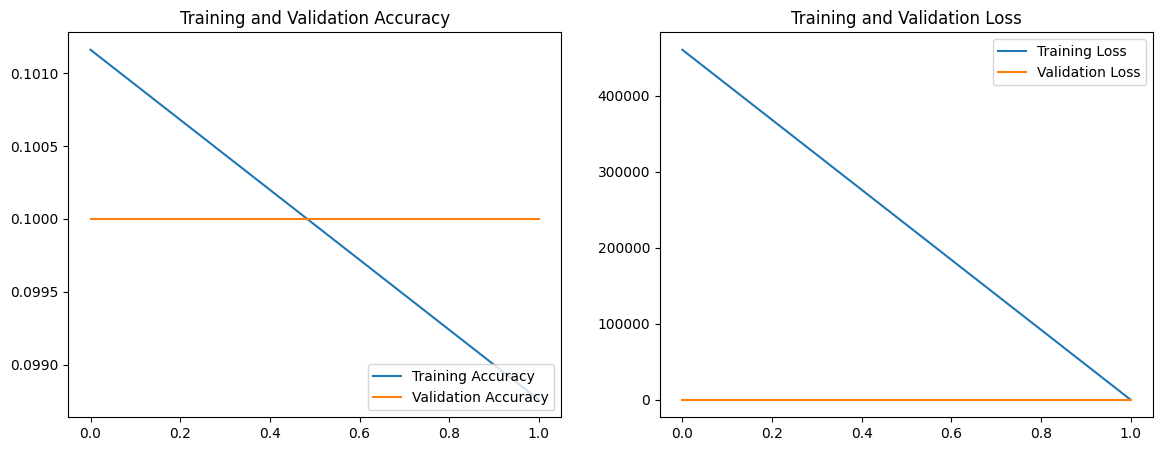

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.savefig('./foo.png')
plt.show()